<a href="https://colab.research.google.com/github/AnisaAisha/procedural-modeling-simulation-of-embroidery/blob/motif-4/Motif4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install taichi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 19.5 MB/s eta 0:00:00


[Taichi] version 1.7.4, llvm 15.0.4, commit b4b956fd, linux, python 3.12.13
[Taichi] Starting on arch=cuda
[+BBBBBHBBBBHBBBBHBBBBHBBBBH][-BBBBBHBBBBHBBBBHBBBBHBBBBH]a[+BBBBB-[+BBBBB-[+BBBBB-F[+BBBBB-]A[+BBBB+++++A]A[+BBB+++++A]A[+BB+++++A]A[+B+++++A]][+BBBBB-]A[+BBBB+++++A]A[+BBB+++++A]A[+BB+++++A]A[+B+++++A]][+BBBBB-]A[+BBBB+++++A]A[+BBB+++++A]A[+BB+++++A]A[+B+++++A]][-BBBBB+[-BBBBB+[-BBBBB+G[-BBBBB+]A[-BBBB-----A]A[-BBB-----A]A[-BB-----A]A[-B-----A]][-BBBBB+]A[-BBBB-----A]A[-BBB-----A]A[-BB-----A]A[-B-----A]][-BBBBB+]A[-BBBB-----A]A[-BBB-----A]A[-BB-----A]A[-B-----A]]A[+BBBB+++++A][-BBBB-----A]A[+BBB+++++A][-BBB-----A]A[+BB+++++A][-BB-----A]A[+B+++++A][-B-----A]


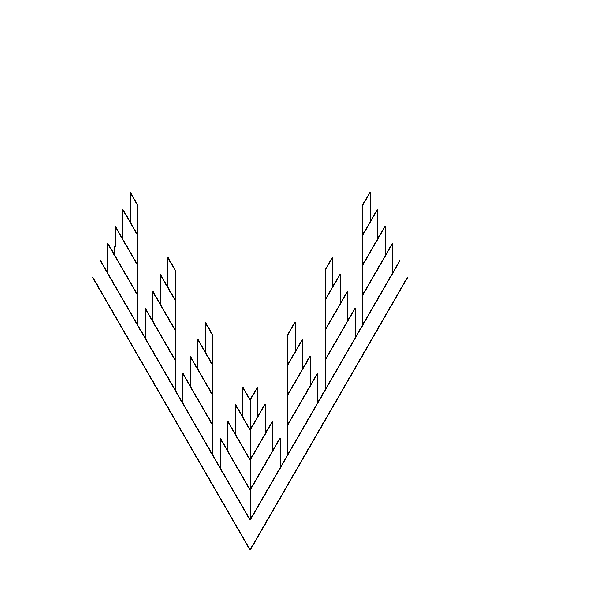

In [ ]:
import taichi as ti
import taichi.math as tm
import numpy as np
from PIL import Image
from IPython.display import display

ti.init(arch=ti.gpu)

axiom = "[+BBHBHBHBHBH][-BBHBHBHBHBH]aFGM"
rule = {"F" : "[+BBBBB-F[+BBBBB-]A[+BBBB+++++A]A[+BBB+++++A]A[+BB+++++A]A[+B+++++A]]",
        'G': "[-BBBBB+G[-BBBBB+]A[-BBBB-----A]A[-BBB-----A]A[-BB-----A]A[-B-----A]]",
        'M': 'A[+BBBB+++++A][-BBBB-----A]A[+BBB+++++A][-BBB-----A]A[+BB+++++A][-BB-----A]A[+B+++++A][-B-----A]',
        'H': 'BH'
        }
#[+BBBBB-[+BBBBB-]A[+BBBB+++++A]A[+BBB+++++A]A[+BB+++++A]A[+B+++++A]F] left pattern
#[-BBBBB+[-BBBBB+]A[-BBBB-----A]A[-BBB-----A]A[-BB-----A]A[-B-----A]G] right pattern
#A[+BBBB+++++A][-BBBB-----A]A[+BBB+++++A][-BBB-----A]A[+BB+++++A][-BB-----A]A[+B+++++A][-B-----A]M middle pattern
def generate_l_system(axiom, rules, iterations):
  current_string = axiom
  temp = ""
  for i in range(iterations):
    for j in current_string:
      if j in rules.keys():
        temp += rules[j]
      else:
        temp += j
    current_string = temp
    temp = ""
  return current_string

final_str = generate_l_system(axiom, rule, 3)
char_to_token = {'A': 1, 'B' : 2, '+': 3, '-': 4, 'a': 5, 'b': 6, '[': 7, ']': 8, 'F': 9, 'G': 10, 'R': 11, 'L': 12, 'H': 13, 'M': 14, 'T': 15}
token_list = [char_to_token[i] for i in final_str]
print(final_str)
token_array = np.array(token_list, dtype=np.int32)
n = 600
pixels = ti.field(dtype=ti.f32, shape=(n, n))
tokens = ti.field(dtype=ti.int32, shape=(len(token_array)))
tokens.from_numpy(token_array)

side_length_A = 30.0
side_length_B = 15.0
angle = 30.0

start_x = ti.field(dtype=ti.f32, shape=(len(token_array)))
start_y = ti.field(dtype=ti.f32, shape=(len(token_array)))
start_angle = ti.field(dtype=ti.f32, shape=(len(token_array)))

stack_x = ti.field(dtype=ti.f32, shape=(50))
stack_y = ti.field(dtype=ti.f32, shape=(50))
stack_angle = ti.field(dtype=ti.f32, shape=(50))
stack_ptr = ti.field(dtype=ti.int32, shape=(1))

@ti.func
def push(x, y, angle):
  stack_x[stack_ptr[0]] = x
  stack_y[stack_ptr[0]] = y
  stack_angle[stack_ptr[0]] = angle
  stack_ptr[0] +=1

@ti.func
def pop():
  temp_x = stack_x[stack_ptr[0]-1]
  temp_y = stack_y[stack_ptr[0]-1]
  temp_z = stack_angle[stack_ptr[0]-1]
  stack_ptr[0] -= 1
  return (temp_x, temp_y, temp_z)

@ti.kernel
def compute_stages(lengthA: float, lengthB: float, angle: float):
  ti.loop_config(serialize=True)

  stack = []
  x = 250.0
  y = 50.0
  alpha = 90.0
  for i in range(tokens.shape[0]):
    start_x[i] = x
    start_y[i] = y
    start_angle[i] = alpha

    t = tokens[i]
    if t == 1 or t == 5:
      x = x + lengthA * ti.cos(alpha* tm.pi/180.0)
      y = y + lengthA * ti.sin(alpha* tm.pi/180.0)
    elif t == 2 or t == 6:
      x = x + lengthB * ti.cos(alpha* tm.pi/180.0)
      y = y + lengthB * ti.sin(alpha* tm.pi/180.0)
    elif t == 3:
      alpha += angle
    elif t == 4:
      alpha -= angle
    elif t == 7:
      push(x, y, alpha)
    elif t == 8:
      x, y, alpha = pop()
    else:
      continue



@ti.kernel
def draw_in_parallel(lengthA: float, lengthB: float):
  for i in range(tokens.shape[0]):
    if tokens[i] == 1:
      x = start_x[i]
      y = start_y[i]
      alpha = start_angle[i]

      x_next = x + lengthA * ti.cos(alpha * tm.pi / 180.0)
      y_next = y + lengthA * ti.sin(alpha * tm.pi / 180.0)

      # Draw the line
      steps = int(lengthA * 2.0)
      for s in range(steps):
        pct = float(s) / float(steps)
        px = int(x + (x_next - x) * pct)
        py = int(y + (y_next - y) * pct)
        if 0 <= px < n and 0 <= py < n:
          pixels[px, py] = 0.0  # Draw line in BLACK
    elif tokens[i] == 2:
      x = start_x[i]
      y = start_y[i]
      alpha = start_angle[i]

      x_next = x + lengthB * ti.cos(alpha * tm.pi / 180.0)
      y_next = y + lengthB * ti.sin(alpha * tm.pi / 180.0)

      # Draw the line
      steps = int(lengthB * 2.0)
      for s in range(steps):
        pct = float(s) / float(steps)
        px = int(x + (x_next - x) * pct)
        py = int(y + (y_next - y) * pct)
        if 0 <= px < n and 0 <= py < n:
          pixels[px, py] = 0.0  # Draw line in BLACK

pixels.fill(1.0)

compute_stages(side_length_A, side_length_B, angle)
draw_in_parallel(side_length_A, side_length_B)

arr = pixels.to_numpy()
arr = np.rot90(arr)
arr = (arr * 255).clip(0, 255).astype(np.uint8)  # normalize to uint8
img = Image.fromarray(arr)
display(img)

# Save the image locally
ti.tools.imwrite(pixels, "image.png")
